In [1]:
using Pkg
Pkg.activate("../18337")
using Gridap, Gridap.Geometry, Gridap.Fields, GridapGmsh
using LinearAlgebra

  Activating project at `c:\Rena\MIT2\18.337\18337`


In [2]:
model = GmshDiscreteModel("coarse_cantileverbeam.msh")
# lc = 0.04 so np around 4436

Info    : Reading 'coarse_cantileverbeam.msh'...
Info    : 13 entities
Info    : 2320 nodes
Info    : 4640 elements
Info    : Done reading 'coarse_cantileverbeam.msh'


UnstructuredDiscreteModel()

In [3]:
# FE spaces for displacement field
order = 1
u_reffe = ReferenceFE(lagrangian, VectorValue{2,Float64}, order)

V = TestFESpace(
    model,
    u_reffe;
    conformity = :H1,
    dirichlet_tags = ["Clamp", "ClampNodes"],
    dirichlet_masks = [(true, true), (true, true)]
)
u_D(x) = VectorValue(0.0, 0.0)

U = TrialFESpace(V, u_D)

TrialFESpace()

In [4]:
# Define integration over certain domains
degree = 2

Ω = Triangulation(model)
dΩ = Measure(Ω, degree)

Ω_d = Triangulation(model, tags = "Design")
dΩ_d = Measure(Ω_d, degree)

Γ_load = BoundaryTriangulation(model; tags = ["Load"])
dΓ_load = Measure(Γ_load, degree)

GenericMeasure()

In [5]:
# FE spaces for design parameters
p_reffe = ReferenceFE(lagrangian, Float64, 0)
Q = TestFESpace(Ω_d, p_reffe, vector_type = Vector{Float64})
P = Q
np = num_free_dofs(P) # Number of cells in design region (number of design parameters)

pf_reffe = ReferenceFE(lagrangian, Float64, 1)
Qf = TestFESpace(Ω_d, pf_reffe, vector_type = Vector{Float64})
Pf = Qf

fem_params = (; V, U, Q, P, Qf, Pf, np, Ω, dΩ, dΩ_d, dΓ_load)
print("np = ", np)

np = 4436

In [6]:
# PHYSICAL PARAMETERS
E0 = 2.5          # Young's modulus of solid material (GPa)
Emin = 1e-3       # small stiffness for "void" material
ν = 0.33          # Poisson's ratio
q_simp = 3        # SIMP penalization exponent
Vf = 0.4          # allowed volume fraction
L = 3          # beam length (m)
H = 1          # beam height (m)
t = 1          # thickness if using 2D plane stress as a physical plate/beam (m), not used if treating as a 2D plane strain problem
f_load = -1.0     # magnitude of downward load (N/m)
traction = VectorValue(0.0, f_load) # downward traction on right edge 
phys_params = (; E0, Emin, ν, q_simp, Vf, L, H, t, traction)

# PROBLEM PARAMETERS
r = 0.5          # Helmholtz filter radius
β = 8                   # β∈[1,∞], threshold sharpness (unused)
η = 0.5                     # η∈[0,1], threshold center

0.5

In [7]:
a_f(r, u, v) = r^2 * (∇(v) ⋅ ∇(u))

function Filter(p0; r, fem_params) 
    ph = FEFunction(fem_params.P, p0)
    op = AffineFEOperator(fem_params.Pf, fem_params.Qf) do u, v
        ∫(a_f(r, u, v))fem_params.dΩ_d + ∫(v * u)fem_params.dΩ_d, ∫(v * ph)fem_params.dΩ_d
      end
    pfh = solve(op)
    return get_free_dof_values(pfh)
end

function Threshold(pfh; β, η)
    return ((tanh(β * η) + tanh(β * (pfh - η))) / (tanh(β * η) + tanh(β * (1.0 - η))))
end

Threshold (generic function with 1 method)

In [8]:
# Problem formulation
struct SIMP{PT} <: Function # New Julia function type for SIMP material model
    params::PT
end

function (s::SIMP)(ρ) # ρ is the design variable (density) at a point
    p = s.params.q_simp
    E0 = s.params.E0
    Emin = s.params.Emin
    return Emin + ρ^p * (E0 - Emin)
end

In [9]:
# Define elasticity tensors and stress-strain relationships
ε(u) = 0.5 * (∇(u) + ∇(u)')
λ(E, ν) = (E * ν) / ((1.0 + ν) * (1.0 - 2.0ν))
μ(E, ν) = E / (2.0 * (1.0 + ν))

const I2 = TensorValue(1.0, 0.0,
                       0.0, 1.0) # 2D identity tensor

function σ_from_E(u, E, poisson)
    lambda_val = λ(E, poisson)
    mu_val = μ(E, poisson)
    strain_u = ε(u)

    return lambda_val * tr(strain_u) * I2 +
           2.0 * mu_val * strain_u
end

function a_base_elastic(u, v; phys_params)
    Emin = phys_params.Emin
    ν = phys_params.ν

    return ε(v) ⊙ σ_from_E(u, Emin, ν)
end

function a_design_elastic(u, v, pth; phys_params)
    E0 = phys_params.E0
    Emin = phys_params.Emin
    ν = phys_params.ν
    q = phys_params.q_simp

    σ0 = σ_from_E(u, E0, ν)
    σmin = σ_from_E(u, Emin, ν)
    simp_pth = ((p -> p^q) ∘ pth)

    return (simp_pth) * (ε(v) ⊙ (σ0 - σmin))
end

function MatrixK(pth; phys_params, fem_params) # full stiffness matrix assembly through LU factorization
    K_mat = assemble_matrix(fem_params.U, fem_params.V) do u, v
        ∫(a_base_elastic(u, v; phys_params))fem_params.dΩ +
        ∫(a_design_elastic(u, v, pth; phys_params))fem_params.dΩ_d
    end

    return lu(K_mat)
end

MatrixK (generic function with 1 method)

In [10]:
# Initial forward solve
p0 = zeros(fem_params.np)  # Here we make p=0 everywhere just for illustration purpose
pf_vec = Filter(p0;r, fem_params)
pfh = FEFunction(fem_params.Pf, pf_vec)
pth = (pf -> Threshold(pf; β, η)) ∘ pfh
K_mat = MatrixK(pth; phys_params = phys_params, fem_params = fem_params)

F_vec = assemble_vector(fem_params.V) do v
    ∫(v ⋅ phys_params.traction)fem_params.dΓ_load
end

u_vec = K_mat \ F_vec
uh = FEFunction(fem_params.U, u_vec)
Γ_clamp = BoundaryTriangulation(model; tags=["Clamp"])
dΓ_clamp = Measure(Γ_clamp, degree)

clamp_motion = sum(∫(uh ⋅ uh)dΓ_clamp)

println("clamp displacement norm squared = ", clamp_motion)
println("Clamp boundary measure = ", sum(∫(1.0)dΓ_clamp))

Γ_load = BoundaryTriangulation(model; tags=["Load"])
dΓ_load_check = Measure(Γ_load, degree)

println("Load boundary measure = ", sum(∫(1.0)dΓ_load_check))
V_unc = TestFESpace(
    model,
    u_reffe;
    conformity = :H1
)

V_con = TestFESpace(
    model,
    u_reffe;
    conformity = :H1,
    dirichlet_tags = ["Clamp", "ClampNodes"],
    dirichlet_masks = [(true, true), (true, true)]
)
println("unconstrained dofs = ", num_free_dofs(V_unc))
println("constrained dofs   = ", num_free_dofs(V_con))

clamp displacement norm squared = 0.0
Clamp boundary measure = 0.9999999999999998
Load boundary measure = 0.49999999999999994
unconstrained dofs = 4640
constrained dofs   = 4588


displacement norm should be 0 -> good

In [11]:
# Objective function (compliance)
function Compliance(u_vec, F_vec)
    return dot(F_vec, u_vec)
end

# Total volume of the design domain
function DesignVolume(; fem_params)
    return sum(∫(1.0)fem_params.dΩ_d)
end

# Physical volume fraction using thresholded density pth
function VolumeFraction(pth; fem_params)
    Vd = DesignVolume(fem_params=fem_params)
    return sum(∫(pth)fem_params.dΩ_d) / Vd
end

# Volume constraint: gV <= 0
function VolumeConstraint(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β=β, η=η)) ∘ pfh
    
    return VolumeFraction(pth; fem_params=fem_params) - phys_params.Vf
end

VolumeConstraint (generic function with 1 method)

### Optimization with Adjoint Method

In [12]:
using ChainRulesCore, Zygote
import ChainRulesCore: rrule
NO_FIELDS = ZeroTangent()

ZeroTangent()

In [13]:
# Some helper derivatives
Dptdpf(pf, β, η) = β * (1.0 - tanh(β * (pf - η))^2) / (tanh(β * η) + tanh(β * (1.0 - η)))

# Derivative of SIMP Young's Modulus w.r.t pf
function DEdpf(pf, phys_params, β, η)
    q = phys_params.q_simp
    E0 = phys_params.E0
    Emin = phys_params.Emin
    
    # Formula: dE/dpth * dpth/dpf
    dE_dpth = q * Threshold(pf; β=β, η=η)^(q - 1) * (E0 - Emin)
    return dE_dpth * Dptdpf(pf, β, η)
end

# Derivative of SIMP density factor w.r.t pf
function DSIMPdpf(pf, phys_params, β, η)
    q = phys_params.q_simp
    
    # Formula: d(pth^q)/dpth * dpth/dpf
    dSIMP_dpth = q * Threshold(pf; β=β, η=η)^(q - 1)
    return dSIMP_dpth * Dptdpf(pf, β, η)
end

# Derivative of the Elasticity Weak Form w.r.t pf
function DKdpf(u, v, pfh; phys_params, β, η)
    E0 = phys_params.E0
    Emin = phys_params.Emin
    ν = phys_params.ν
    
    # Base stress tensors
    σ0 = σ_from_E(u, E0, ν)
    σmin = σ_from_E(u, Emin, ν)
    
    # Map the SIMP derivative over the domain
    dSIMP_func = p -> DSIMPdpf(p, phys_params, β, η)
    
    return (dSIMP_func ∘ pfh) * (ε(v) ⊙ (σ0 - σmin))
end

# Compliance objective as a function of filtered density pf
function gf_pf(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β = β, η = η)) ∘ pfh
    
    # Solve forward displacement
    K_mat = MatrixK(pth; phys_params = phys_params, fem_params = fem_params)

    F_vec = assemble_vector(fem_params.V) do v
        ∫(v ⋅ phys_params.traction)fem_params.dΓ_load
    end

    u_vec = K_mat \ F_vec
    
    # Compliance objective: g = Fᵀu
    return dot(F_vec, u_vec)
end

#### Adjoint Objective Derivative (`Dgfdpf`)
# This calculates the gradient of the compliance with respect to the filtered variables pf.

function Dgfdpf(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β=β, η=η)) ∘ pfh
    
    # Solve forward displacement
    K_mat = MatrixK(pth; phys_params=phys_params, fem_params=fem_params)
    F_vec = assemble_vector(v -> ∫(v ⋅ phys_params.traction)fem_params.dΓ_load, fem_params.V)
    u_vec = K_mat \ F_vec
    uh = FEFunction(fem_params.U, u_vec)
    
    # Compliance is self-adjoint: adjoint field w = uh
    # Sensitivity = -∫ [ uh * (dK/dpf) * uh ] dΩ
    l_temp(dp) = ∫( -1.0 * DKdpf(uh, uh, pfh; phys_params=phys_params, β=β, η=η) * dp )fem_params.dΩ_d
    
    return assemble_vector(l_temp, fem_params.Qf)
end


#### Filter Adjoint (`Dgdp`)
# This propagates the gradient from the filtered space pf back to the design variables p.

function Dgdp(dgdpf; r, fem_params)
    # Assemble the Filter PDE matrix (Af)
    Af = assemble_matrix(fem_params.Pf, fem_params.Qf) do u, v
        ∫(a_f(r, u, v))fem_params.dΩ_d + ∫(v * u)fem_params.dΩ_d
    end
    
    # Adjoint solve for the filter (Af is symmetric)
    wvec = Af' \ dgdpf
    wh = FEFunction(fem_params.Pf, wvec)
    
    # Convert sensitivity back to the piece-wise constant space P
    return assemble_vector(dp -> ∫(wh * dp)fem_params.dΩ_d, fem_params.P)
end

Dgdp (generic function with 1 method)

In [14]:
### Custom adjoint rules
# Helmholtz filter forward and backward rules for AD
# Forward map: p -> pf
function pf_p0(p0; r, fem_params)
    pf_vec = Filter(p0; r = r, fem_params = fem_params)
    return pf_vec
end

# Custom reverse rule for p -> pf
function ChainRulesCore.rrule(::typeof(pf_p0), p0; r, fem_params)

    function pf_pullback(dgdpf)
        # dgdpf is ∂g/∂pf coming from later in the computational graph
        dgdpf_vec = unthunk(dgdpf)

        # Pull gradient back through the Helmholtz filter:
        # dg/dp = Mᵀ Af^{-T} dg/dpf
        dgdp = Dgdp(dgdpf_vec; r = r, fem_params = fem_params)

        return NoTangent(), dgdp
    end

    return pf_p0(p0; r = r, fem_params = fem_params), pf_pullback
end

# Custom reverse rule for pf -> compliance
function ChainRulesCore.rrule(::typeof(gf_pf), pf_vec; β, η, phys_params, fem_params)

    function gf_pullback(dgdg)
        # dgdg is the upstream scalar sensitivity.
        # Usually dgdg = 1.0 if this is the final scalar objective.
        dgdg_val = unthunk(dgdg)

        # Local derivative: dg/dpf
        dgfdpf = Dgfdpf(pf_vec; β = β, η = η, phys_params = phys_params, fem_params = fem_params)

        return NoTangent(), dgdg_val * dgfdpf
    end

    return gf_pf(pf_vec; β = β, η = η, phys_params = phys_params, fem_params = fem_params), gf_pullback
end

In [15]:
# FULL compliance objective as a function of raw design variables p0
function gf_p(p0::Vector; r, β, η, phys_params, fem_params)
    pf_vec = pf_p0(p0; r = r, fem_params = fem_params)
    gf_pf(pf_vec; β = β, η = η, phys_params = phys_params, fem_params = fem_params)
end

# compute dg/dp_0 using Zygote and the custom adjoint rules defined above
# Calculated gradient AND objective value for NLopt
# NLopt-compatible compliance objective
function gf_p(p0::Vector, grad::Vector; r, β, η, phys_params, fem_params)
    if length(grad) > 0
        dgdp, = Zygote.gradient(p -> gf_p(p; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params), p0)
        grad[:] = dgdp
    end

    gvalue = gf_p(p0; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params)

    open("coarse_beam/gvalue.txt", "a") do io
        write(io, "$gvalue \n")
    end

    return gvalue
end

gf_p (generic function with 2 methods)

In [16]:
using Printf

βtest = 1.0
ηtest = 0.5

# Choose a stable interior design point
p_test = clamp.(fill(phys_params.Vf, fem_params.np) .+ 0.05 .* randn(fem_params.np), 0.1, 0.9)

println("p_test extrema = ", extrema(p_test))

# Random normalized direction
d = randn(fem_params.np)
d ./= norm(d)

# Compute adjoint gradient at p_test
grad = zeros(fem_params.np)
g0 = gf_p(p_test, grad; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

adj_dir = dot(grad, d)

println("g0 = ", g0)
println("norm grad = ", norm(grad))
println("grad extrema = ", extrema(grad))
println("adj_dir = ", adj_dir)

for h in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    p_plus = p_test + h*d

    println("h = ", h, ", p_plus extrema = ", extrema(p_plus))

    g1 = gf_p(p_plus; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

    fd_dir = (g1 - g0) / h
    rel_error = abs(fd_dir - adj_dir) / max(abs(fd_dir), abs(adj_dir), eps())

    @printf("h = %.1e, g1 = %.8e, fd_dir = %.8e, adj_dir = %.8e, rel_error = %.8e\n",
            h, g1, fd_dir, adj_dir, rel_error)
end

p_test extrema = (0.22532994229833336, 0.5763223704375207)
g0 = 169.33596698443802
norm grad = 24.108987702450023
grad extrema = (-0.798196747513584, -0.03921676149205179)
adj_dir = 0.025015294490086777
h = 0.01, p_plus extrema = (0.22535817657600632, 0.5762712266788693)
h = 1.0e-02, g1 = 1.69336217e+02, fd_dir = 2.50208204e-02, adj_dir = 2.50152945e-02, rel_error = 2.20851421e-04
h = 0.001, p_plus extrema = (0.22533276572610067, 0.5763172560616555)
h = 1.0e-03, g1 = 1.69335992e+02, fd_dir = 2.50159492e-02, adj_dir = 2.50152945e-02, rel_error = 2.61707817e-05
h = 0.0001, p_plus extrema = (0.2253302246411101, 0.5763218589999342)
h = 1.0e-04, g1 = 1.69335969e+02, fd_dir = 2.50158314e-02, adj_dir = 2.50152945e-02, rel_error = 2.14627039e-05
h = 1.0e-5, p_plus extrema = (0.22532997053261103, 0.576322319293762)
h = 1.0e-05, g1 = 1.69335967e+02, fd_dir = 2.50180392e-02, adj_dir = 2.50152945e-02, rel_error = 1.09709068e-04
h = 1.0e-6, p_plus extrema = (0.22532994512176113, 0.5763223653231448)

In [17]:
println(typeof(fem_params.V))
println(typeof(fem_params.U))

labels = get_face_labeling(model)

println("Clamp tag = ", get_tag_from_name(labels, "Clamp"))
println("Load tag = ", get_tag_from_name(labels, "Load"))
println("Design tag = ", get_tag_from_name(labels, "Design"))

p_solid = fill(1.0, fem_params.np)
p_uniform = fill(phys_params.Vf, fem_params.np)
p_void = fill(0.0, fem_params.np)

g_solid = gf_p(p_solid; r=r, β=1.0, η=0.5, phys_params=phys_params, fem_params=fem_params)
g_uniform = gf_p(p_uniform; r=r, β=1.0, η=0.5, phys_params=phys_params, fem_params=fem_params)
g_void = gf_p(p_void; r=r, β=1.0, η=0.5, phys_params=phys_params, fem_params=fem_params)

println("g_solid = ", g_solid)
println("g_uniform = ", g_uniform)
println("g_void = ", g_void)

Gridap.FESpaces.UnconstrainedFESpace{Vector{Float64}, Gridap.FESpaces.NodeToDofGlue{VectorValue{2, Int32}}}
TrialFESpace{Gridap.FESpaces.UnconstrainedFESpace{Vector{Float64}, Gridap.FESpaces.NodeToDofGlue{VectorValue{2, Int32}}}}
Clamp tag = 6
Load tag = 4
Design tag = 7
g_solid = 10.393419100876004
g_uniform = 171.26362997642565
g_void = 25983.547752157938


Negative extrema: increasing density decreases compliance (as expected)

Moving in random direction d decreases compliance locally

Error improves as h decreases, then gets worse again as roundoff dominates

In [18]:
dgdpf = Dgfdpf(pf_vec; β=8.0, η=0.5, phys_params=phys_params, fem_params=fem_params)
println("norm dgdpf = ", norm(dgdpf), ", extrema = ", extrema(dgdpf))

dgdp = Dgdp(dgdpf; r=r, fem_params=fem_params)
println("norm dgdp = ", norm(dgdp), ", extrema = ", extrema(dgdp))

grad = zeros(fem_params.np)
g0 = gf_p(p0, grad; r=r, β=8.0, η=0.5, phys_params=phys_params, fem_params=fem_params)
println("norm grad from gf_p = ", norm(grad), ", extrema = ", extrema(grad))

norm dgdpf = 0.0, extrema = (0.0, 0.0)
norm dgdp = 0.0, extrema = (0.0, 0.0)
norm grad from gf_p = 0.0, extrema = (0.0, 0.0)


In [19]:
# Derivative of volume constraint w.r.t filtered variables pf
function DgVdpf(pf_vec; β, η, phys_params, fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    Vd = DesignVolume(fem_params=fem_params)
    
    # Map threshold derivative over the domain
    dpt_func = pf -> Dptdpf(pf, β, η)
    
    # Formula: dVolume/dpf = (1 / |Ωd|) * dpt/dpf
    l_temp(dp) = ∫( dp * (dpt_func ∘ pfh) / Vd )fem_params.dΩ_d
    
    return assemble_vector(l_temp, fem_params.Qf)
end

# Derivative of volume constraint w.r.t raw design variables p
function DgVdp(p0; r, β, η, phys_params, fem_params)
    pf_vec = pf_p0(p0; r=r, fem_params=fem_params)
    
    # Compute derivative w.r.t filtered variables pf
    dgVdpf = DgVdpf(pf_vec; β=β, η=η, phys_params=phys_params, fem_params=fem_params)
    
    # Pull gradient back through the Helmholtz filter
    return Dgdp(dgVdpf; r=r, fem_params=fem_params)
end

# NLopt-compatible volume constraint
function gV_p(p0::Vector, grad::Vector; r, β, η, phys_params, fem_params)
    pf_vec = pf_p0(p0; r=r, fem_params=fem_params)
    
    if length(grad) > 0
        grad[:] = DgVdp(p0; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params)
    end
    
    gVvalue = VolumeConstraint(pf_vec; β=β, η=η, phys_params=phys_params, fem_params=fem_params)
    
    return gVvalue
end
# if gV_p(p0, grad; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params) <= 0, constraint is satisfied

gV_p (generic function with 1 method)

In [20]:
# Test the volume constraint gradient implementation by comparing to finite differences
βtest = 1.0
ηtest = 0.5

p0 = rand(fem_params.np)

d = randn(fem_params.np)
d ./= norm(d)

gradV = zeros(fem_params.np)
gV0 = gV_p(p0, gradV; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

adj_dir = dot(gradV, d)

println("gV0 = ", gV0)
println("norm gradV = ", norm(gradV))
println("gradV extrema = ", extrema(gradV))
println("adj_dir = ", adj_dir)

for h in [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
    gV1 = gV_p(p0 + h*d, []; r=r, β=βtest, η=ηtest, phys_params=phys_params, fem_params=fem_params)

    fd_dir = (gV1 - gV0) / h
    rel_error = abs(fd_dir - adj_dir) / max(abs(fd_dir), abs(adj_dir), eps())

    @printf("h = %.1e, fd_dir = %.8e, adj_dir = %.8e, rel_error = %.8e\n",
            h, fd_dir, adj_dir, rel_error)
end

gV0 = 0.09639716419706679
norm gradV = 0.01628588031487304
gradV extrema = (0.0001245177537463263, 0.0003256196146742634)
adj_dir = -5.15072288383353e-5
h = 1.0e-02, fd_dir = -5.15072284e-05, adj_dir = -5.15072288e-05, rel_error = 8.63573537e-09
h = 1.0e-03, fd_dir = -5.15072270e-05, adj_dir = -5.15072288e-05, rel_error = 3.49324731e-08
h = 1.0e-04, fd_dir = -5.15072085e-05, adj_dir = -5.15072288e-05, rel_error = 3.94896015e-07
h = 1.0e-05, fd_dir = -5.15071763e-05, adj_dir = -5.15072288e-05, rel_error = 1.01998240e-06
h = 1.0e-06, fd_dir = -5.15059106e-05, adj_dir = -5.15072288e-05, rel_error = 2.55923439e-05


### Optimization with MMA

In [21]:
# Doubling beta scheme (Sigmund 2007)
# Minimize objective
# Include volume constraint
# Runs a sequence of MMA optimizations, each for 50 iterations, and feeds the previous optimized design into the next sharper projection stage.
using NLopt
using DelimitedFiles
using Serialization

# NLopt for fixed beta 
function gf_p_optimize(p_init; r, β, η, TOL = 1e-4, MAX_ITER = 50, phys_params, fem_params, history = nothing)
    opt = Opt(:LD_MMA, fem_params.np)

    opt.lower_bounds = zeros(fem_params.np)
    opt.upper_bounds = ones(fem_params.np)

    opt.ftol_rel = TOL
    opt.maxeval = MAX_ITER

    # Minimize compliance: g(p) = Fᵀu
    opt.min_objective = (p0, grad) -> begin
        gvalue = gf_p(p0, grad; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params)

        if history !== nothing
            push!(history[:g], gvalue)
            push!(history[:β], β)
            push!(history[:η], η)
            push!(history[:vol], gV_p(p0, []; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params) + phys_params.Vf)
        end

        return gvalue
    end

    # Volume constraint: gV(p) <= 0
    inequality_constraint!(opt, (p0, grad) -> gV_p(p0, grad; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params), 1e-8)

    (g_opt, p_opt, ret) = optimize(opt, p_init)

    @show numevals = opt.numevals

    return g_opt, p_opt, ret
end

# Continuation scheme with doubling beta
function gf_p_optimize_doubling(p_init; r, η, TOL = 1e-8, ITER_PER_BETA = 50, β_START = 1.0, β_MAX = 512.0, phys_params, fem_params, save_prefix = "sensitivity_beam")
    ##################### Initialize #####################
    p_opt = copy(p_init)
    g_opt = Inf
    β = β_START

    history = Dict(
        :g => Float64[],
        :β => Float64[],
        :η => Float64[],
        :vol => Float64[],
        :stage_g => Float64[],
        :stage_β => Float64[],
        :stage_η => Float64[],
        :stage_vol => Float64[],
        :stage_ret => String[]
    )

    if !isdir(save_prefix)
        mkdir(save_prefix)
    end

    stage = 1

    ##################### Continuation #####################
    while β <= β_MAX
        println("Starting MMA stage $stage with β = $β, η = $η")

        g_opt, p_temp_opt, ret = gf_p_optimize(
            p_opt;
            r = r,
            β = β,
            η = η,
            TOL = TOL,
            MAX_ITER = ITER_PER_BETA,
            phys_params = phys_params,
            fem_params = fem_params,
            history = history
        )

        p_opt = copy(p_temp_opt)

        vol = gV_p(p_opt, []; r=r, β=β, η=η, phys_params=phys_params, fem_params=fem_params) + phys_params.Vf

        push!(history[:stage_g], g_opt)
        push!(history[:stage_β], β)
        push!(history[:stage_η], η)
        push!(history[:stage_vol], vol)
        push!(history[:stage_ret], string(ret))

        # Save checkpoint p and metadata
        serialize(joinpath(save_prefix, "p_stage_$(stage)_beta_$(Int(round(β))).jls"), p_opt)

        open(joinpath(save_prefix, "stage_history.csv"), "a") do io
            write(io, "$stage,$β,$η,$g_opt,$vol,$ret\n")
        end

        global_stage_msg = "Finished stage $stage: β = $β, g = $g_opt, volume = $vol, ret = $ret"
        println(global_stage_msg)

        β *= 2.0
        stage += 1
    end

    ##################### Save full history #####################
    writedlm(joinpath(save_prefix, "g_history.csv"), hcat(history[:g], history[:β], history[:η], history[:vol]), ',')

    serialize(joinpath(save_prefix, "p_final.jls"), p_opt)

    return g_opt, p_opt, history
end

gf_p_optimize_doubling (generic function with 1 method)

### Set up Experiments

In [32]:
##################### Spatially Biased Initializations #####################

function design_cell_centers(fem_params)
    cell_coords = get_cell_coordinates(fem_params.Ω)

    centers = map(cell_coords) do coords
        c = zero(coords[1])
        for x in coords
            c += x
        end
        c / length(coords)
    end

    return collect(centers)
end

function rescale_to_volume_fraction(p, Vf; lo=0.05, hi=0.95)
    p_scaled = copy(p)
    p_scaled .*= Vf / mean(p_scaled)
    return clamp.(p_scaled, lo, hi)
end

rescale_to_volume_fraction (generic function with 1 method)

In [33]:
# ============ Set up different initialization designs ================
using Random
using Statistics

# Different initialization strategies for p
function make_initial_design(kind; fem_params, phys_params, seed=1)
    Random.seed!(seed)
    np = fem_params.np
    Vf = phys_params.Vf

    if kind == :uniform
        # Starts exactly at the target volume fraction
        return fill(Vf, np)

    elseif kind == :random_small
        # Small random perturbation around Vf
        return clamp.(Vf .+ 0.05 .* randn(np), 0.05, 0.95)

    elseif kind == :random_large
        # Larger random perturbation around Vf
        return clamp.(Vf .+ 0.20 .* randn(np), 0.05, 0.95)
    
    elseif kind in [:left_heavy, :right_heavy, :top_heavy, :bottom_heavy]
        centers = design_cell_centers(fem_params)

        xs = [x[1] for x in centers]
        ys = [x[2] for x in centers]

        xhat = (xs .- minimum(xs)) ./ (maximum(xs) - minimum(xs) + eps())
        yhat = (ys .- minimum(ys)) ./ (maximum(ys) - minimum(ys) + eps())

        if kind == :left_heavy
            # More material near the clamp side, less near the load side
            bias = 1.0 .- xhat

        elseif kind == :right_heavy
            # More material near the load side
            bias = xhat

        elseif kind == :top_heavy
            # More material near the top edge
            bias = yhat

        elseif kind == :bottom_heavy
            # More material near the bottom edge
            bias = 1.0 .- yhat
        end

        # Keep densities away from exact 0/1, then rescale mean near Vf
        p = 0.15 .+ 0.70 .* bias
        return rescale_to_volume_fraction(p, Vf)

    else
        error("Unknown initialization kind: $kind")
    end
end

make_initial_design (generic function with 1 method)

In [34]:
# Grayness metric for final projected density
function Grayness(p0; r, β, η, fem_params)
    pf_vec = pf_p0(p0; r=r, fem_params=fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β=β, η=η)) ∘ pfh

    Vd = sum(∫(1.0)fem_params.dΩ_d)

    gray = sum(∫(4.0 * pth * (1.0 - pth))fem_params.dΩ_d) / Vd
    return gray
end

# Compute final objective, volume, constraint value, and grayness
function final_metrics(p_final; r, β_final, η, phys_params, fem_params)
    g_final = gf_p(p_final; r=r, β=β_final, η=η, phys_params=phys_params, fem_params=fem_params)
    gV_final = gV_p(p_final,[]; r=r, β=β_final, η=η, phys_params=phys_params, fem_params=fem_params)

    vol_final = gV_final + phys_params.Vf
    gray_final = Grayness(p_final; r=r, β=β_final, η=η, fem_params=fem_params)

    return g_final, vol_final, gV_final, gray_final
end

final_metrics (generic function with 1 method)

In [35]:
# some helpers for saving/loading results to run tests in batches

function sensitivity_paths(; base_folder="SensitivityBeam", experiment_name="init_sensitivity")
    experiment_folder = joinpath(base_folder, experiment_name)
    results_file = joinpath(experiment_folder, "$(experiment_name)_results.jls")
    csv_file = joinpath(experiment_folder, "$(experiment_name)_summary.csv")

    if !isdir(experiment_folder)
        mkpath(experiment_folder)
    end

    return experiment_folder, results_file, csv_file
end

function save_results(results; outfile)
    serialize(outfile, results)
end

function load_results(; outfile)
    if isfile(outfile)
        return deserialize(outfile)
    else
        return NamedTuple[]
    end
end

function save_results_csv(results; outfile)
    open(outfile, "w") do io
        write(io, "run_id,kind,seed,g_final,vol_final,gV_final,gray_final,total_evals,runtime,save_prefix\n")
        for r in results
            write(io, "$(r.run_id),$(r.kind),$(r.seed),$(r.g_final),$(r.vol_final),$(r.gV_final),$(r.gray_final),$(r.total_evals),$(r.runtime),$(r.save_prefix)\n")
        end
    end
end

function already_ran(results, kind, seed)
    return any(r -> r.kind == string(kind) && r.seed == seed, results)
end

already_ran (generic function with 1 method)

In [36]:
# Run sensitivty tests in batches

function run_initialization_sensitivity_batch(; init_jobs, r, η, TOL=1e-8, ITER_PER_BETA=50, β_START=1.0, β_MAX=512.0, phys_params, fem_params, base_folder="SensitivityBeam", experiment_name="init_sensitivity")
    experiment_folder, results_file, csv_file = sensitivity_paths(base_folder=base_folder, experiment_name=experiment_name)

    results = load_results(outfile=results_file)
    run_id = length(results) + 1

    for job in init_jobs
        kind = job.kind
        seed = job.seed

        if already_ran(results, kind, seed)
            println("Skipping kind = $kind, seed = $seed because it already exists.")
            continue
        end

        println("==================================================")
        println("Run $run_id: kind = $kind, seed = $seed")
        println("Saving under: ", experiment_folder)
        println("==================================================")

        p_init = make_initial_design(kind; fem_params=fem_params, phys_params=phys_params, seed=seed)

        save_prefix = joinpath(experiment_folder, "run_$(run_id)_$(kind)_seed_$(seed)")

        t_run = @elapsed begin
            g_opt_run, p_opt_run, history_run = gf_p_optimize_doubling(p_init; r=r, η=η, TOL=TOL, ITER_PER_BETA=ITER_PER_BETA, β_START=β_START, β_MAX=β_MAX, phys_params=phys_params, fem_params=fem_params, save_prefix=save_prefix)
        end

        β_final = β_MAX

        g_final, vol_final, gV_final, gray_final = final_metrics(p_opt_run; r=r, β_final=β_final, η=η, phys_params=phys_params, fem_params=fem_params)

        total_evals = length(history_run[:g])

        serialize(joinpath(save_prefix, "p_init.jls"), p_init)
        serialize(joinpath(save_prefix, "p_final.jls"), p_opt_run)

        push!(results, (run_id=run_id, kind=string(kind), seed=seed, g_final=g_final, vol_final=vol_final, gV_final=gV_final, gray_final=gray_final, total_evals=total_evals, runtime=t_run, save_prefix=save_prefix))

        save_results(results; outfile=results_file)
        save_results_csv(results; outfile=csv_file)

        println("Finished run $run_id")
        println("g_final = ", g_final)
        println("vol_final = ", vol_final)
        println("gV_final = ", gV_final)
        println("gray_final = ", gray_final)
        println("runtime = ", t_run)
        println("Saved cumulative results to ", results_file)
        println("Saved CSV summary to ", csv_file)

        run_id += 1
    end

    return results
end

run_initialization_sensitivity_batch (generic function with 1 method)

In [29]:
# Run experiments - batch 1
jobs_1 = [
    (kind=:uniform, seed=1),
    (kind=:random_small, seed=1),
    (kind=:random_small, seed=2)
]

results = run_initialization_sensitivity_batch(
    init_jobs=jobs_1;
    r=r,
    η=0.5,
    TOL=1e-8,
    ITER_PER_BETA=50,
    β_START=1.0,
    β_MAX=512.0,
    phys_params=phys_params,
    fem_params=fem_params,
    base_folder="SensitivityBeam",
    experiment_name="init_sensitivity")

Run 1: kind = uniform, seed = 1
Saving under: SensitivityBeam\init_sensitivity
Starting MMA stage 1 with β = 1.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 1: β = 1.0, g = 99.65515048992518, volume = 0.3999882111980643, ret = MAXEVAL_REACHED
Starting MMA stage 2 with β = 2.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 2: β = 2.0, g = 96.0414356055808, volume = 0.39999878799712263, ret = MAXEVAL_REACHED
Starting MMA stage 3 with β = 4.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 3: β = 4.0, g = 86.91008458396105, volume = 0.399998801226, ret = MAXEVAL_REACHED
Starting MMA stage 4 with β = 8.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 4: β = 8.0, g = 73.83941722527184, volume = 0.3999895577860705, ret = MAXEVAL_REACHED
Starting MMA stage 5 with β = 16.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 5: β = 16.0, g = 63.68191531700385, volume = 0.3999438829954209, ret = MAXEVAL_REACHED
Starting MMA stage 6 with β = 32.0, η = 0.5
numevals = opt

3-element Vector{NamedTuple}:
 (run_id = 1, kind = "uniform", seed = 1, g_final = 29.93409191249281, vol_final = 0.39957186084308705, gV_final = -0.00042813915691297666, gray_final = 0.12862698306997095, total_evals = 500, runtime = 171.2660013, save_prefix = "SensitivityBeam\\init_sensitivity\\run_1_uniform_seed_1")
 (run_id = 2, kind = "random_small", seed = 1, g_final = 28.89409639723627, vol_final = 0.3999979984487539, gV_final = -2.0015512461335483e-6, gray_final = 0.1250368399157584, total_evals = 500, runtime = 184.4269228, save_prefix = "SensitivityBeam\\init_sensitivity\\run_2_random_small_seed_1")
 (run_id = 3, kind = "random_small", seed = 2, g_final = 28.647312971846006, vol_final = 0.39989832850806517, gV_final = -0.00010167149193485159, gray_final = 0.13173040971917743, total_evals = 500, runtime = 179.455161, save_prefix = "SensitivityBeam\\init_sensitivity\\run_3_random_small_seed_2")

In [30]:
jobs_2 = [
    (kind=:random_small, seed=3),
    (kind=:random_large, seed=1),
    (kind=:random_large, seed=2),
    (kind=:random_large, seed=3)
]

results = run_initialization_sensitivity_batch(
    init_jobs=jobs_2;
    r=r,
    η=0.5,
    TOL=1e-8,
    ITER_PER_BETA=50,
    β_START=1.0,
    β_MAX=512.0,
    phys_params=phys_params,
    fem_params=fem_params,
    base_folder="SensitivityBeam",
    experiment_name="init_sensitivity"
)

Run 4: kind = random_small, seed = 3
Saving under: SensitivityBeam\init_sensitivity
Starting MMA stage 1 with β = 1.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 1: β = 1.0, g = 99.73807735765924, volume = 0.3999973414008687, ret = MAXEVAL_REACHED
Starting MMA stage 2 with β = 2.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 2: β = 2.0, g = 96.0475613835783, volume = 0.3999985883896752, ret = MAXEVAL_REACHED
Starting MMA stage 3 with β = 4.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 3: β = 4.0, g = 86.91464788609649, volume = 0.39999755582104074, ret = MAXEVAL_REACHED
Starting MMA stage 4 with β = 8.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 4: β = 8.0, g = 73.8658667564823, volume = 0.39999972649074517, ret = MAXEVAL_REACHED
Starting MMA stage 5 with β = 16.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 5: β = 16.0, g = 63.63049587961932, volume = 0.39995068601573486, ret = MAXEVAL_REACHED
Starting MMA stage 6 with β = 32.0, η = 0.5
nume

7-element Vector{NamedTuple}:
 (run_id = 1, kind = "uniform", seed = 1, g_final = 29.93409191249281, vol_final = 0.39957186084308705, gV_final = -0.00042813915691297666, gray_final = 0.12862698306997095, total_evals = 500, runtime = 171.2660013, save_prefix = "SensitivityBeam\\init_sensitivity\\run_1_uniform_seed_1")
 (run_id = 2, kind = "random_small", seed = 1, g_final = 28.89409639723627, vol_final = 0.3999979984487539, gV_final = -2.0015512461335483e-6, gray_final = 0.1250368399157584, total_evals = 500, runtime = 184.4269228, save_prefix = "SensitivityBeam\\init_sensitivity\\run_2_random_small_seed_1")
 (run_id = 3, kind = "random_small", seed = 2, g_final = 28.647312971846006, vol_final = 0.39989832850806517, gV_final = -0.00010167149193485159, gray_final = 0.13173040971917743, total_evals = 500, runtime = 179.455161, save_prefix = "SensitivityBeam\\init_sensitivity\\run_3_random_small_seed_2")
 (run_id = 4, kind = "random_small", seed = 3, g_final = 29.49933490357609, vol_final 

In [39]:
jobs_spatial = [
    (kind=:left_heavy, seed=1),
    (kind=:right_heavy, seed=1),
    (kind=:top_heavy, seed=1),
    (kind=:bottom_heavy, seed=1)
]
results = run_initialization_sensitivity_batch(
    init_jobs=jobs_spatial;
    r=r,
    η=0.5,
    TOL=1e-8,
    ITER_PER_BETA=50,
    β_START=1.0,
    β_MAX=512.0,
    phys_params=phys_params,
    fem_params=fem_params,
    base_folder="SensitivityBeam",
    experiment_name="init_sensitivity"
)

Run 8: kind = left_heavy, seed = 1
Saving under: SensitivityBeam\init_sensitivity
Starting MMA stage 1 with β = 1.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 1: β = 1.0, g = 99.62149507939498, volume = 0.39999265145477364, ret = MAXEVAL_REACHED
Starting MMA stage 2 with β = 2.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 2: β = 2.0, g = 96.05812128882145, volume = 0.39999463156042575, ret = MAXEVAL_REACHED
Starting MMA stage 3 with β = 4.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 3: β = 4.0, g = 86.91484717179006, volume = 0.3999968133294941, ret = MAXEVAL_REACHED
Starting MMA stage 4 with β = 8.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 4: β = 8.0, g = 73.87840423132617, volume = 0.3999893006721537, ret = MAXEVAL_REACHED
Starting MMA stage 5 with β = 16.0, η = 0.5
numevals = opt.numevals = 50
Finished stage 5: β = 16.0, g = 63.70164628564063, volume = 0.3999583908956131, ret = MAXEVAL_REACHED
Starting MMA stage 6 with β = 32.0, η = 0.5
numev

11-element Vector{NamedTuple}:
 (run_id = 1, kind = "uniform", seed = 1, g_final = 29.93409191249281, vol_final = 0.39957186084308705, gV_final = -0.00042813915691297666, gray_final = 0.12862698306997095, total_evals = 500, runtime = 171.2660013, save_prefix = "SensitivityBeam\\init_sensitivity\\run_1_uniform_seed_1")
 (run_id = 2, kind = "random_small", seed = 1, g_final = 28.89409639723627, vol_final = 0.3999979984487539, gV_final = -2.0015512461335483e-6, gray_final = 0.1250368399157584, total_evals = 500, runtime = 184.4269228, save_prefix = "SensitivityBeam\\init_sensitivity\\run_2_random_small_seed_1")
 (run_id = 3, kind = "random_small", seed = 2, g_final = 28.647312971846006, vol_final = 0.39989832850806517, gV_final = -0.00010167149193485159, gray_final = 0.13173040971917743, total_evals = 500, runtime = 179.455161, save_prefix = "SensitivityBeam\\init_sensitivity\\run_3_random_small_seed_2")
 (run_id = 4, kind = "random_small", seed = 3, g_final = 29.49933490357609, vol_final

In [40]:
# Check out all results
experiment_folder, results_file, csv_file = sensitivity_paths(base_folder="SensitivityBeam", experiment_name="init_sensitivity")

results = load_results(outfile=results_file)
println("Number of completed runs = ", length(results))

for r in results
    println("run_id=$(r.run_id), kind=$(r.kind), seed=$(r.seed), g=$(r.g_final), vol=$(r.vol_final), gray=$(r.gray_final)")
end

Number of completed runs = 11
run_id=1, kind=uniform, seed=1, g=29.93409191249281, vol=0.39957186084308705, gray=0.12862698306997095
run_id=2, kind=random_small, seed=1, g=28.89409639723627, vol=0.3999979984487539, gray=0.1250368399157584
run_id=3, kind=random_small, seed=2, g=28.647312971846006, vol=0.39989832850806517, gray=0.13173040971917743
run_id=4, kind=random_small, seed=3, g=29.49933490357609, vol=0.3999637420894803, gray=0.13517453099796414
run_id=5, kind=random_large, seed=1, g=28.814448086031103, vol=0.39974543568398985, gray=0.1294244257863314
run_id=6, kind=random_large, seed=2, g=29.693087812713554, vol=0.3999806687348436, gray=0.13227348696443364
run_id=7, kind=random_large, seed=3, g=29.194867040008166, vol=0.3998124785715667, gray=0.13299646049830166
run_id=8, kind=left_heavy, seed=1, g=28.655069571680478, vol=0.3998731787588761, gray=0.1324832611174293
run_id=9, kind=right_heavy, seed=1, g=29.227756610927987, vol=0.3999705336540897, gray=0.13035875045323997
run_id=10

In [41]:
# Summary stats
g_vals = [r.g_final for r in results]
vol_vals = [r.vol_final for r in results]
gV_vals = [r.gV_final for r in results]
gray_vals = [r.gray_final for r in results]
time_vals = [r.runtime for r in results]
eval_vals = [r.total_evals for r in results]

println("========== Initialization Sensitivity Summary ==========")

println("Number of runs = ", length(results))

println("\nCompliance:")
println("  mean = ", mean(g_vals))
println("  std  = ", std(g_vals))
println("  min  = ", minimum(g_vals))
println("  max  = ", maximum(g_vals))
println("  coeff variation = ", std(g_vals) / mean(g_vals))

println("\nVolume fraction:")
println("  mean = ", mean(vol_vals))
println("  std  = ", std(vol_vals))
println("  min  = ", minimum(vol_vals))
println("  max  = ", maximum(vol_vals))

println("\nConstraint value gV = volume - Vf:")
println("  mean = ", mean(gV_vals))
println("  std  = ", std(gV_vals))
println("  min  = ", minimum(gV_vals))
println("  max  = ", maximum(gV_vals))
println("  max violation = ", maximum(max.(gV_vals, 0.0)))

println("\nGrayness:")
println("  mean = ", mean(gray_vals))
println("  std  = ", std(gray_vals))
println("  min  = ", minimum(gray_vals))
println("  max  = ", maximum(gray_vals))

println("\nRuntime:")
println("  mean = ", mean(time_vals))
println("  std  = ", std(time_vals))
println("  min  = ", minimum(time_vals))
println("  max  = ", maximum(time_vals))

println("\nObjective evaluations:")
println("  mean = ", mean(eval_vals))
println("  std  = ", std(eval_vals))
println("  min  = ", minimum(eval_vals))
println("  max  = ", maximum(eval_vals))

========== Initialization Sensitivity Summary ==========
Number of runs = 11

Compliance:
  mean = 29.245201092629465
  std  = 0.45855546818786797
  min  = 28.647312971846006
  max  = 29.93409191249281
  coeff variation = 0.015679682513909457

Volume fraction:
  mean = 0.39988135297321425
  std  = 0.00012937249199529985
  min  = 0.39957186084308705
  max  = 0.3999979984487539

Constraint value gV = volume - Vf:
  mean = -0.00011864702678580288
  std  = 0.00012937249199529985
  min  = -0.00042813915691297666
  max  = -2.0015512461335483e-6
  max violation = 0.0

Grayness:
  mean = 0.13233730920619607
  std  = 0.004843430619691866
  min  = 0.1250368399157584
  max  = 0.1443993478660476

Runtime:
  mean = 171.3431203
  std  = 13.155398589151638
  min  = 149.8156848
  max  = 192.2648222

Objective evaluations:
  mean = 500.0
  std  = 0.0
  min  = 500
  max  = 500


In [46]:
# Plot Initialization Sensitivity

function plot_initialization_sensitivity(results; phys_params, outfile=joinpath("SensitivityBeam", "init_sensitivity", "init_sensitivity_summary.png"))
    labels = ["$(r.kind)\nseed $(r.seed)" for r in results]

    g_vals = [r.g_final for r in results]
    vol_vals = [r.vol_final for r in results]
    gV_vals = [r.gV_final for r in results]
    gray_vals = [r.gray_final for r in results]
    time_vals = [r.runtime for r in results]

    x = 1:length(results)

    fig = CairoMakie.Figure(size=(1400, 850))

    ax1 = CairoMakie.Axis(fig[1, 1], title="Final Compliance by Initialization", xlabel="Run", ylabel="Compliance g")
    CairoMakie.scatter!(ax1, x, g_vals)
    ax1.xticks = (x, labels)
    ax1.xticklabelrotation = π / 4

    ax2 = CairoMakie.Axis(fig[1, 2], title="Final Volume Fraction", xlabel="Run", ylabel="Volume fraction")
    CairoMakie.scatter!(ax2, x, vol_vals)
    CairoMakie.hlines!(ax2, [phys_params.Vf], linestyle=:dash)
    ax2.xticks = (x, labels)
    ax2.xticklabelrotation = π / 4

    ax3 = CairoMakie.Axis(fig[2, 1], title="Final Constraint Value", xlabel="Run", ylabel="gV = volume - Vf")
    CairoMakie.scatter!(ax3, x, gV_vals)
    CairoMakie.hlines!(ax3, [0.0], linestyle=:dash)
    ax3.xticks = (x, labels)
    ax3.xticklabelrotation = π / 4

    ax4 = CairoMakie.Axis(fig[2, 2], title="Final Grayness", xlabel="Run", ylabel="Grayness")
    CairoMakie.scatter!(ax4, x, gray_vals)
    ax4.xticks = (x, labels)
    ax4.xticklabelrotation = π / 4

    ax5 = CairoMakie.Axis(fig[3, 1:2], title="Runtime by Initialization", xlabel="Run", ylabel="Runtime (s)")
    CairoMakie.scatter!(ax5, x, time_vals)
    ax5.xticks = (x, labels)
    ax5.xticklabelrotation = π / 4

    CairoMakie.save(outfile, fig)

    return fig
end

plot_initialization_sensitivity (generic function with 1 method)

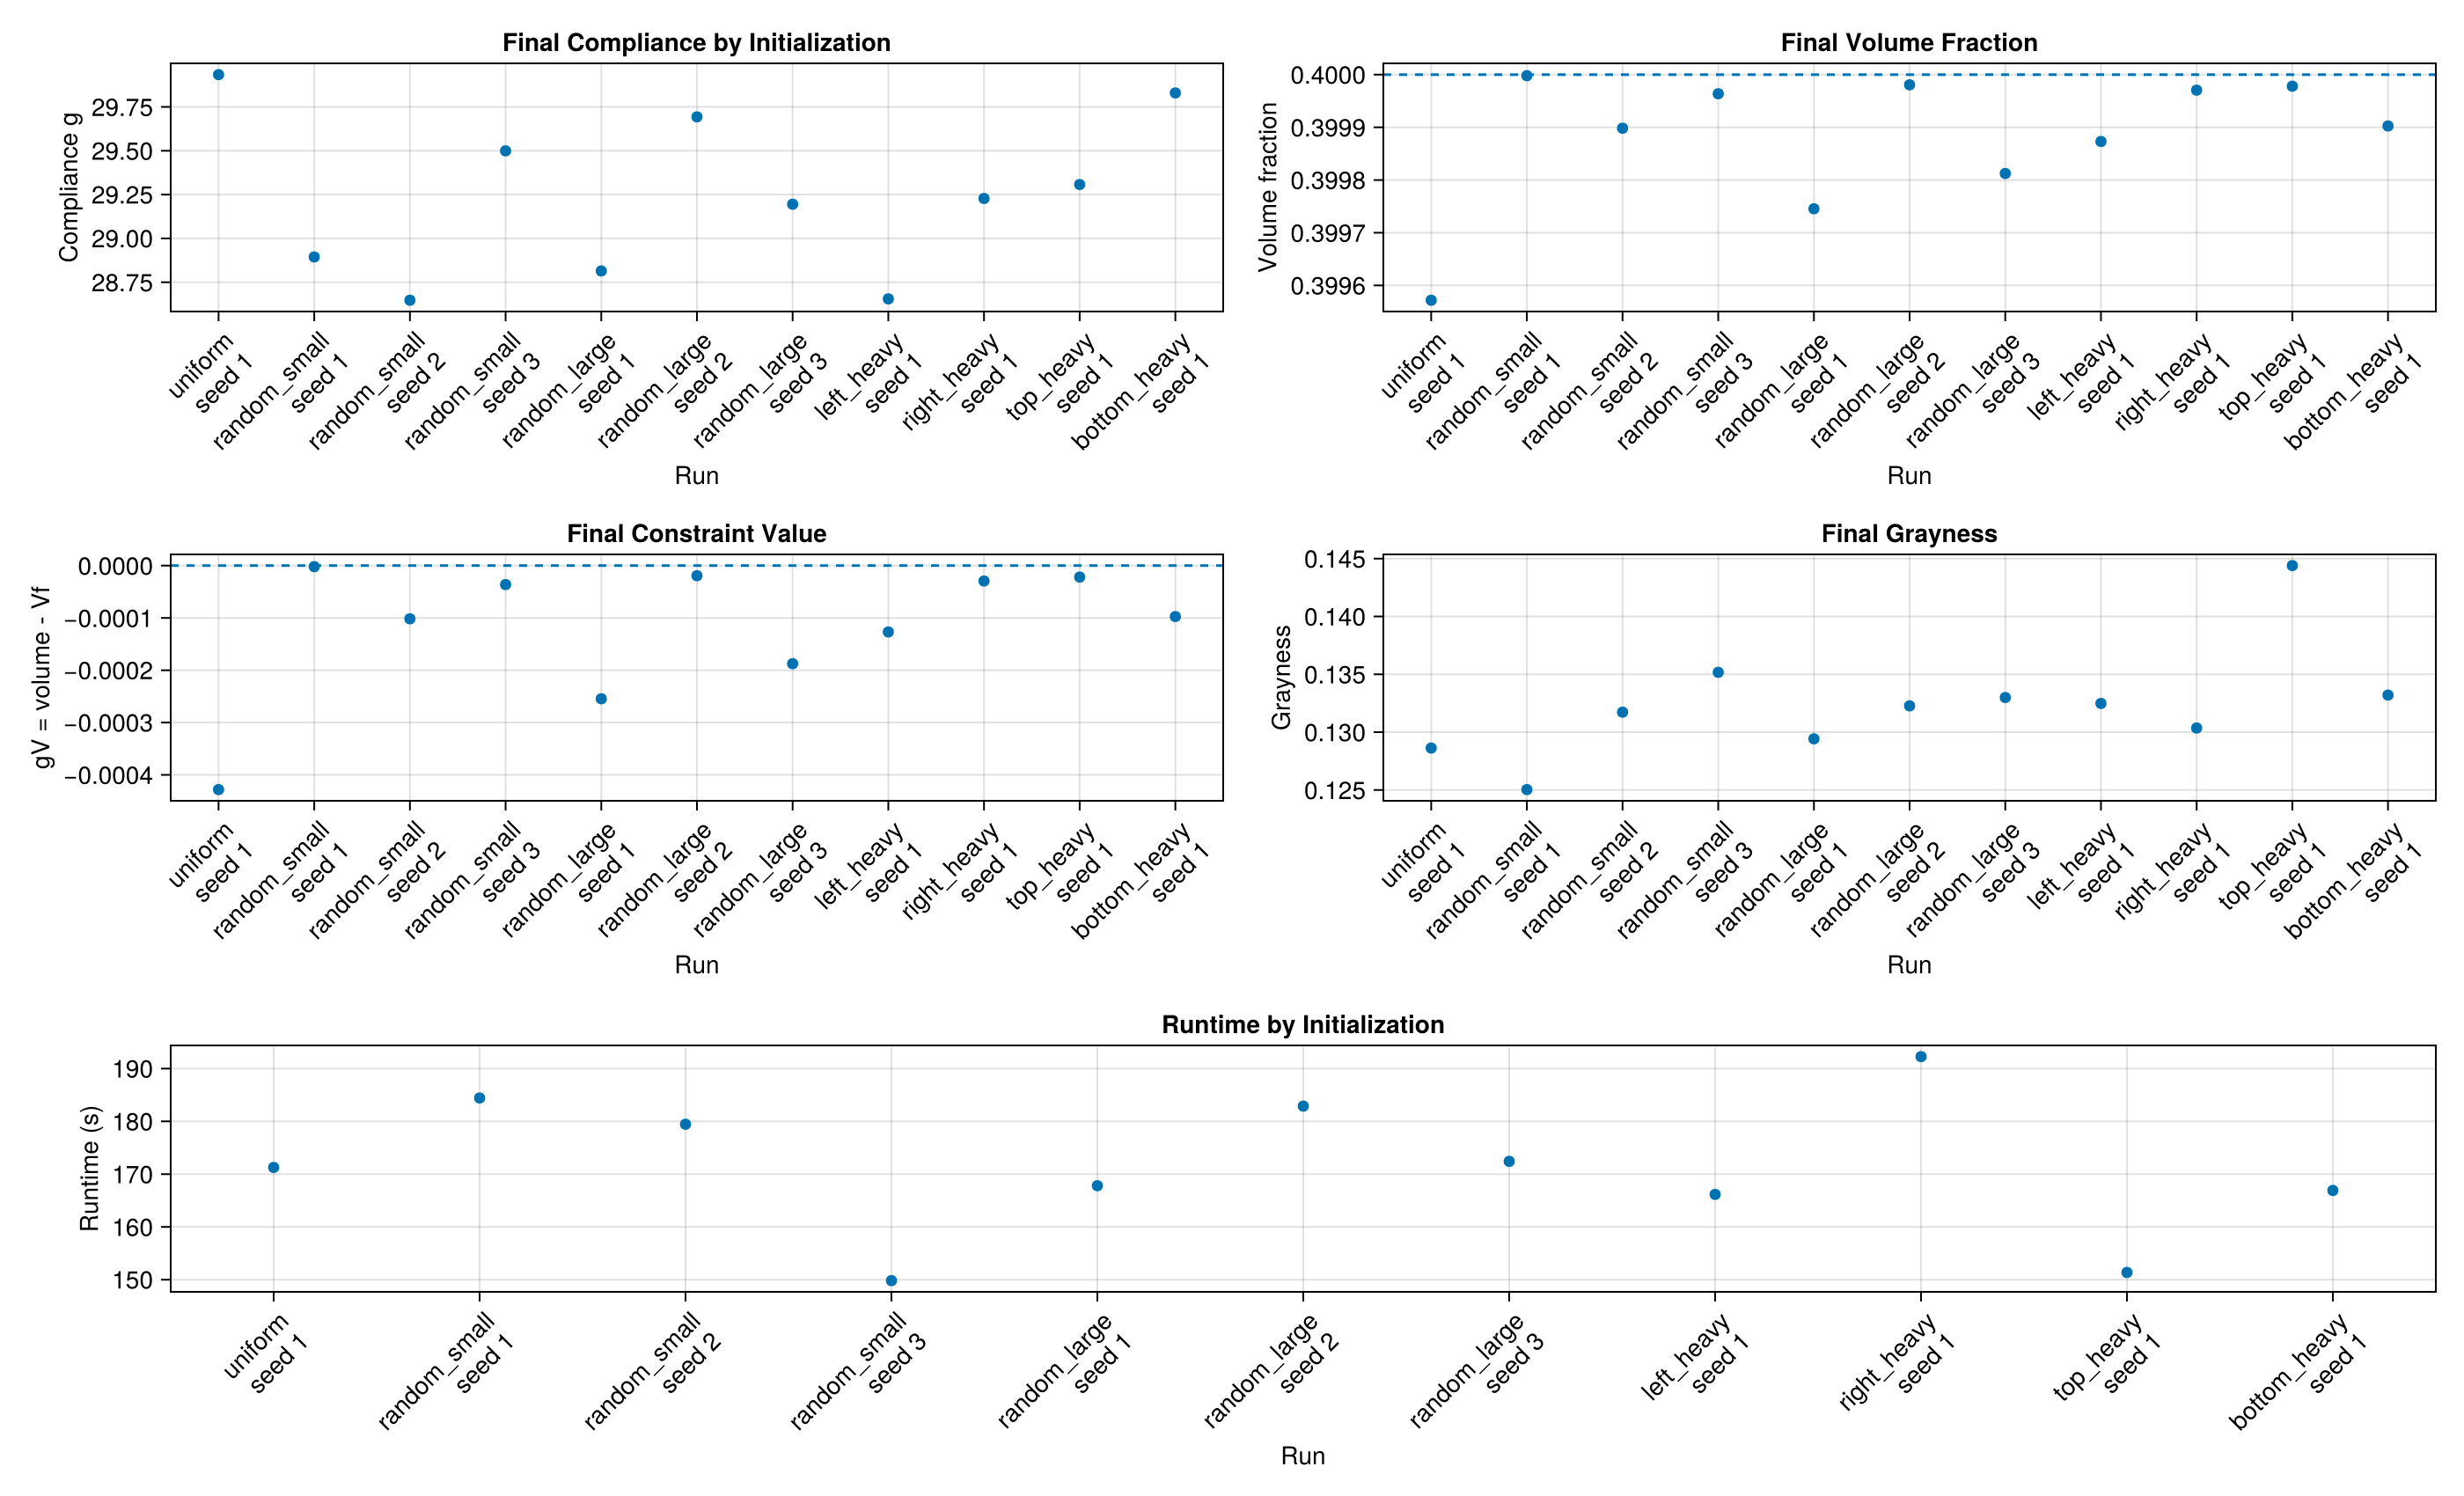

In [47]:
using CairoMakie, GridapMakie
fig = plot_initialization_sensitivity(
    results;
    phys_params=phys_params,
    outfile=joinpath("SensitivityBeam", "init_sensitivity", "init_sensitivity_summary.png")
)

### Visualize results

In [48]:
using CairoMakie, GridapMakie

# Checkpoint file/file reading utilities
function get_checkpoint_metadata(save_prefix)
    files = readdir(save_prefix)
    ckpt_files = filter(f -> occursin(r"^p_stage_\d+_beta_\d+\.jls$", f), files)

    meta = NamedTuple[]
    for f in ckpt_files
        m = match(r"^p_stage_(\d+)_beta_(\d+)\.jls$", f)
        stage = parse(Int, m.captures[1])
        β_stage = parse(Float64, m.captures[2])

        push!(meta, (stage = stage, β = β_stage, path = joinpath(save_prefix, f)))
    end

    sort!(meta, by = x -> x.stage)
    return meta
end

function load_stage_history(save_prefix)
    history_file = joinpath(save_prefix, "stage_history.csv")

    if !isfile(history_file)
        return nothing
    end

    raw = readdlm(history_file, ',', Any)

    hist = Dict{Int, NamedTuple}()

    for i in 1:size(raw, 1)
        stage = parse(Int, string(raw[i, 1]))
        β     = parse(Float64, string(raw[i, 2]))
        η     = parse(Float64, string(raw[i, 3]))
        g     = parse(Float64, string(raw[i, 4]))
        vol   = parse(Float64, string(raw[i, 5]))
        ret   = string(raw[i, 6])

        hist[stage] = (β = β, η = η, g = g, vol = vol, ret = ret)
    end

    return hist
end

load_stage_history (generic function with 1 method)

In [52]:
##################### Plot One Checkpoint #####################

function checkpoint_pth(p_vec, β_stage; r, η, fem_params)
    pf_vec = pf_p0(p_vec; r = r, fem_params = fem_params)
    pfh = FEFunction(fem_params.Pf, pf_vec)
    pth = (pf -> Threshold(pf; β = β_stage, η = η)) ∘ pfh
    return pth
end

##################### Plot All Checkpoints #####################

function plot_checkpoint_shapes(save_prefix; r, η, fem_params, ncols = 5, outfile = "checkpoint_shapes.png")
    ##################### Load Data #####################
    meta = get_checkpoint_metadata(save_prefix)
    hist = load_stage_history(save_prefix)

    nplots = length(meta)
    nrows = cld(nplots, ncols)

    ##################### Make Figure #####################
    fig = Figure(size = (640 * ncols, 500 * nrows))

    last_plt = nothing

    for (k, info) in enumerate(meta)
        row = cld(k, ncols)
        col = k - (row - 1) * ncols

        p_vec = deserialize(info.path)
        pth = checkpoint_pth(p_vec, info.β; r = r, η = η, fem_params = fem_params)

        ax = Axis(fig[row, col], aspect = DataAspect())

        # Plot the thresholded design field
        last_plt = CairoMakie.plot!(ax, fem_params.Ω, pth, colormap = :binary, colorrange = (0.0, 1.0))

        # Clean up axis appearance
        hidedecorations!(ax)
        hidespines!(ax)

        # Build title
        if hist !== nothing && haskey(hist, info.stage)
            g_stage = hist[info.stage].g
            vol_stage = hist[info.stage].vol
            ax.title = @sprintf("Stage %d | β = %.0f\n g = %.3e | vol = %.3f",
                                info.stage, info.β, g_stage, vol_stage)
        else
            ax.title = @sprintf("Stage %d | β = %.0f", info.stage, info.β)
        end
    end

    ##################### Add Colorbar #####################
    if last_plt !== nothing
        Colorbar(fig[:, ncols + 1], last_plt, label = "Thresholded density")
    end

    ##################### Save Figure #####################
    save(outfile, fig)
    return fig
end

plot_checkpoint_shapes (generic function with 1 method)

In [55]:
# Plot ALL final designs in the same plot
function plot_all_final_sensitivity_designs(results; r, η, β_final, fem_params, ncols=4, outfile=joinpath("SensitivityBeam", "init_sensitivity", "final_designs_all_initializations.png"))
    nplots = length(results)
    nrows = cld(nplots, ncols)

    fig = Figure(size=(520 * ncols, 400 * nrows))

    last_plt = nothing

    for (k, result) in enumerate(results)
        row = cld(k, ncols)
        col = k - (row - 1) * ncols

        p_final = deserialize(joinpath(result.save_prefix, "p_final.jls"))
        pth = checkpoint_pth(p_final, β_final; r=r, η=η, fem_params=fem_params)

        ax = Axis(fig[row, col], aspect=DataAspect())

        last_plt = CairoMakie.plot!(ax, fem_params.Ω, pth, colormap=:binary, colorrange=(0.0, 1.0))

        hidedecorations!(ax)
        hidespines!(ax)

        ax.title = "Run $(result.run_id): $(result.kind), seed $(result.seed)\n" *
                   @sprintf("g = %.3e | vol = %.3f", result.g_final, result.vol_final)
    end

    if last_plt !== nothing
        Colorbar(fig[:, ncols + 1], last_plt, label="Thresholded density")
    end

    save(outfile, fig)

    return fig
end

plot_all_final_sensitivity_designs (generic function with 1 method)

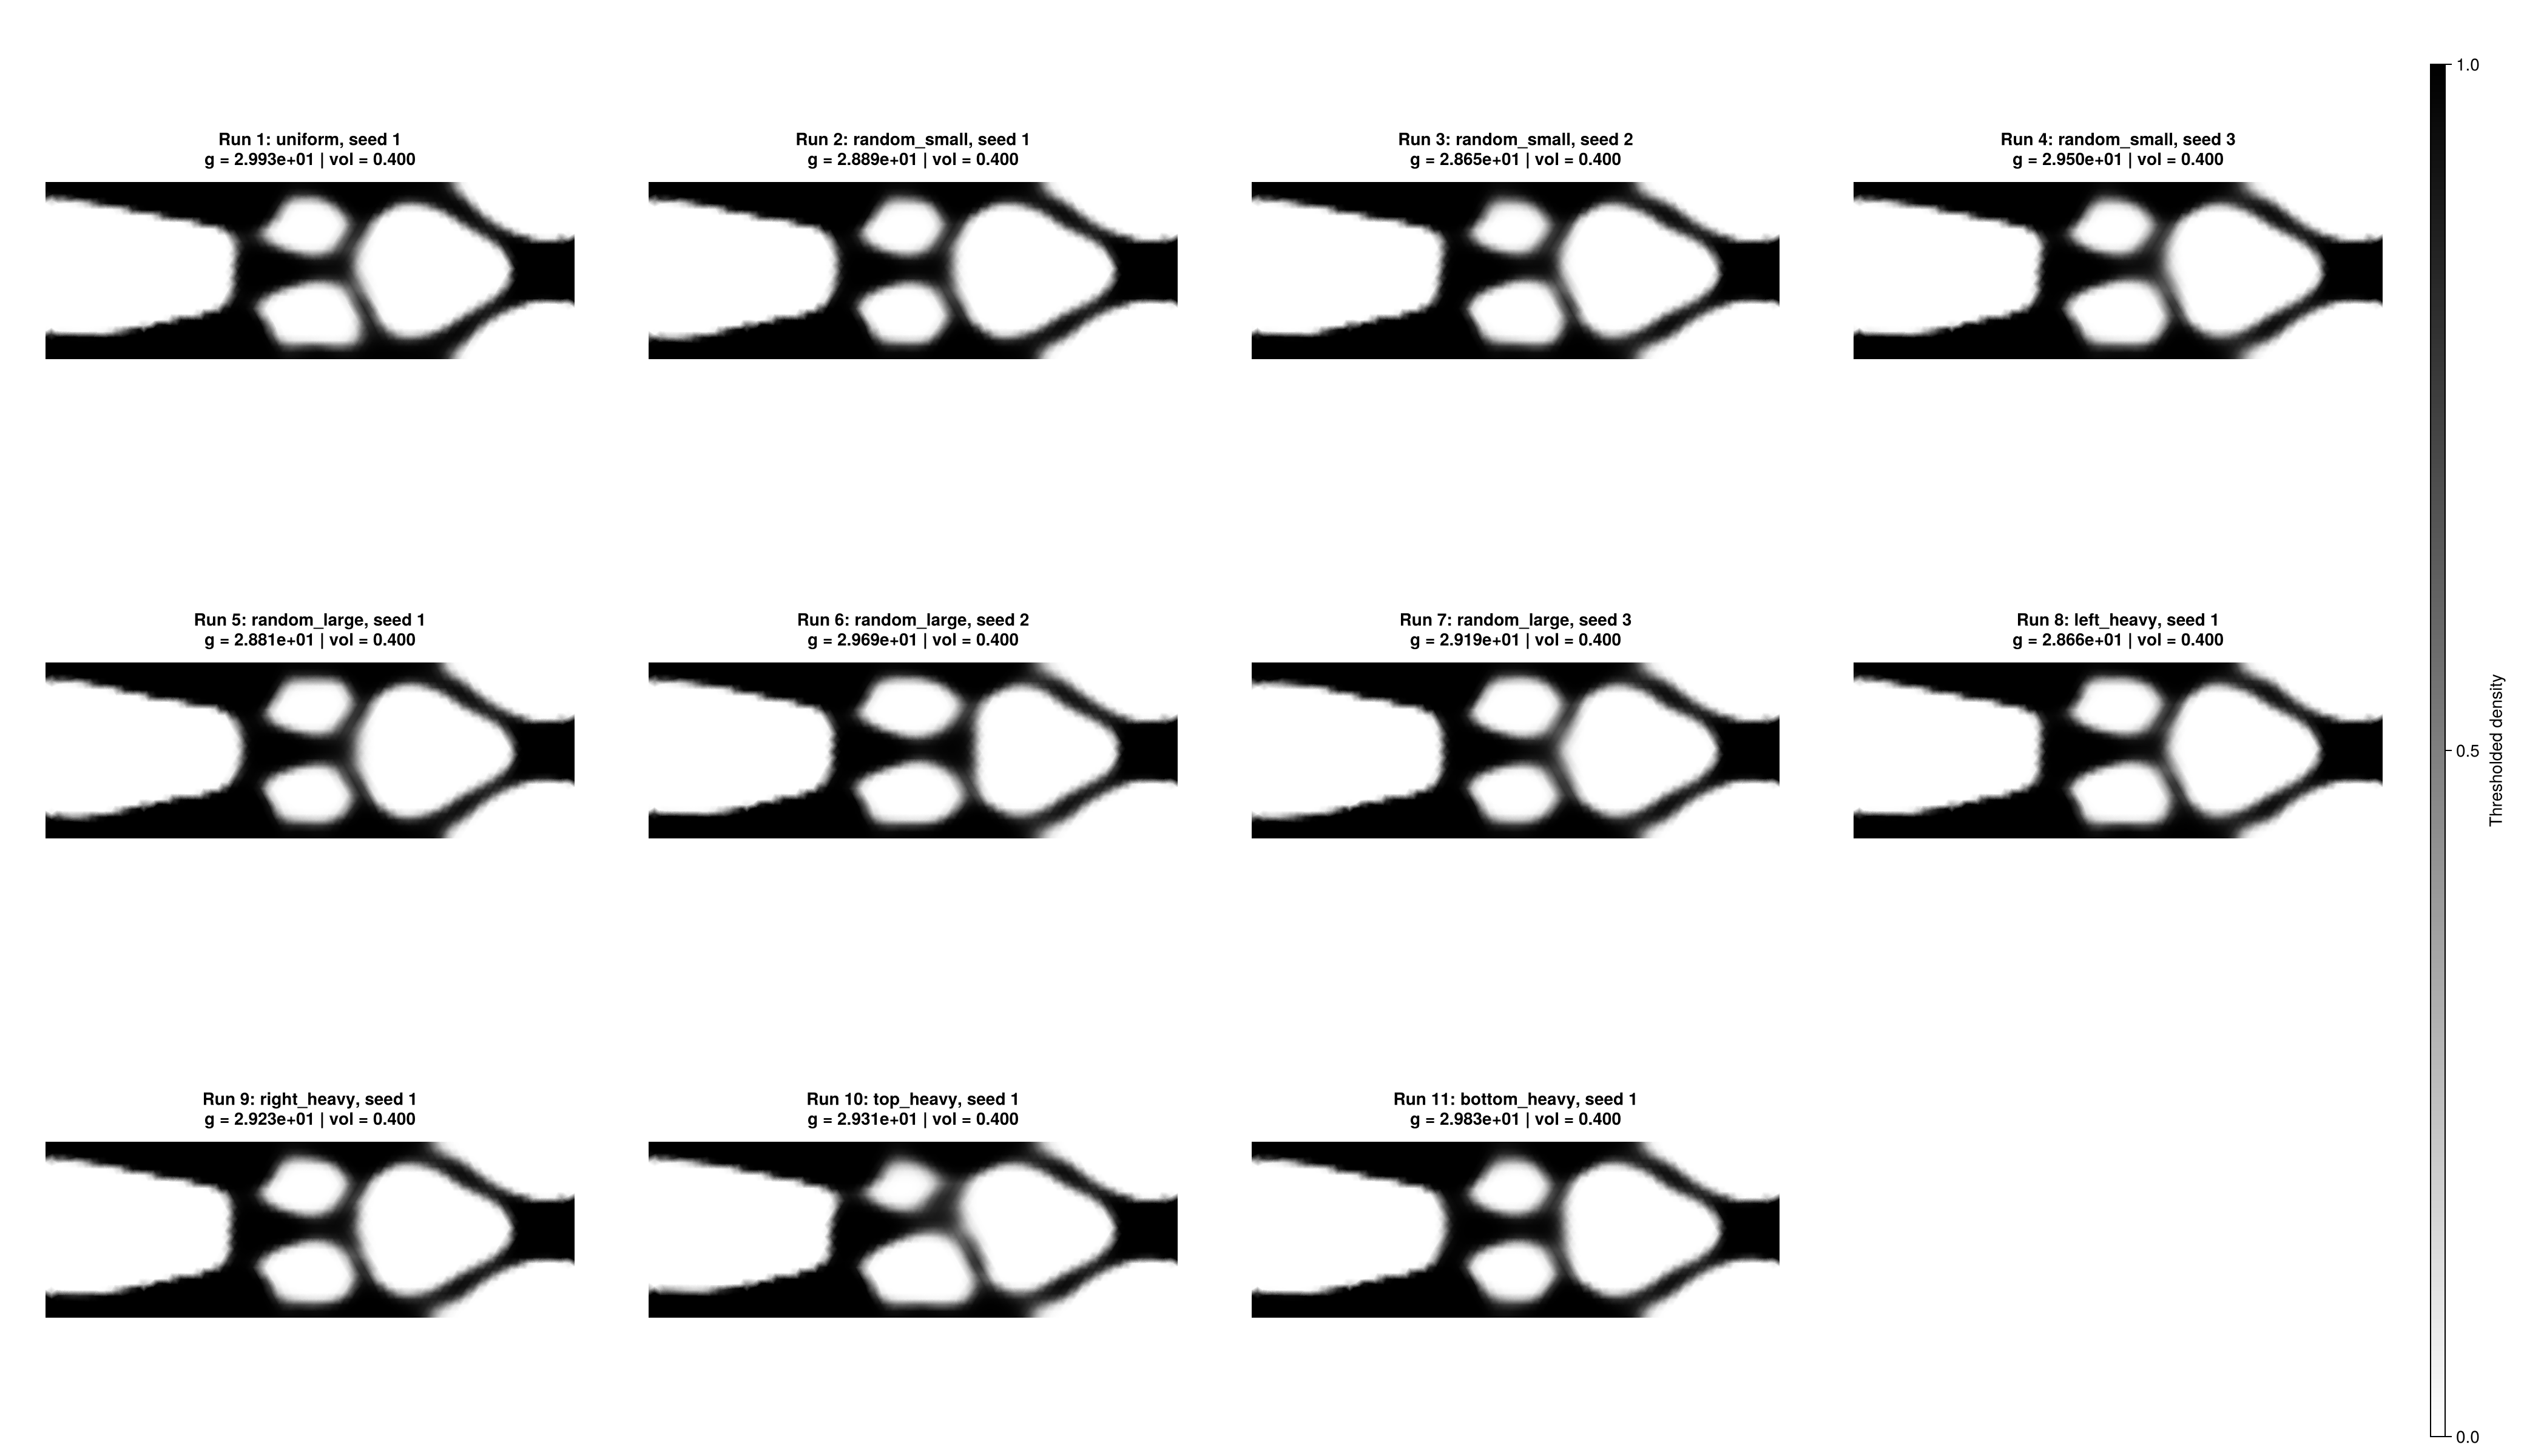

In [56]:
fig_final = plot_all_final_sensitivity_designs(
    results;
    r=r,
    η=0.5,
    β_final=512.0,
    fem_params=fem_params,
    ncols=4,
    outfile=joinpath("SensitivityBeam", "init_sensitivity", "final_designs_all_initializations.png")
)

In [57]:
function plot_all_initial_sensitivity_designs(results; r, η, β_init=1.0, fem_params, ncols=4, outfile=joinpath("SensitivityBeam", "init_sensitivity", "initial_designs_all_initializations.png"))
    nplots = length(results)
    nrows = cld(nplots, ncols)

    fig = CairoMakie.Figure(size=(520 * ncols, 400 * nrows))

    last_plt = nothing

    for (k, result) in enumerate(results)
        row = cld(k, ncols)
        col = k - (row - 1) * ncols

        p_init = deserialize(joinpath(result.save_prefix, "p_init.jls"))

        # Convert raw p_init -> filtered/projected physical density
        pth_init = checkpoint_pth(p_init, β_init; r=r, η=η, fem_params=fem_params)

        ax = CairoMakie.Axis(fig[row, col], aspect=CairoMakie.DataAspect())

        last_plt = CairoMakie.plot!(
            ax,
            fem_params.Ω,
            pth_init,
            colormap=:binary,
            colorrange=(0.0, 1.0)
        )

        CairoMakie.hidedecorations!(ax)
        CairoMakie.hidespines!(ax)

        ax.title = "Run $(result.run_id): $(result.kind), seed $(result.seed)\ninitial density"
    end
    CairoMakie.save(outfile, fig)

    return fig
end

plot_all_initial_sensitivity_designs (generic function with 1 method)

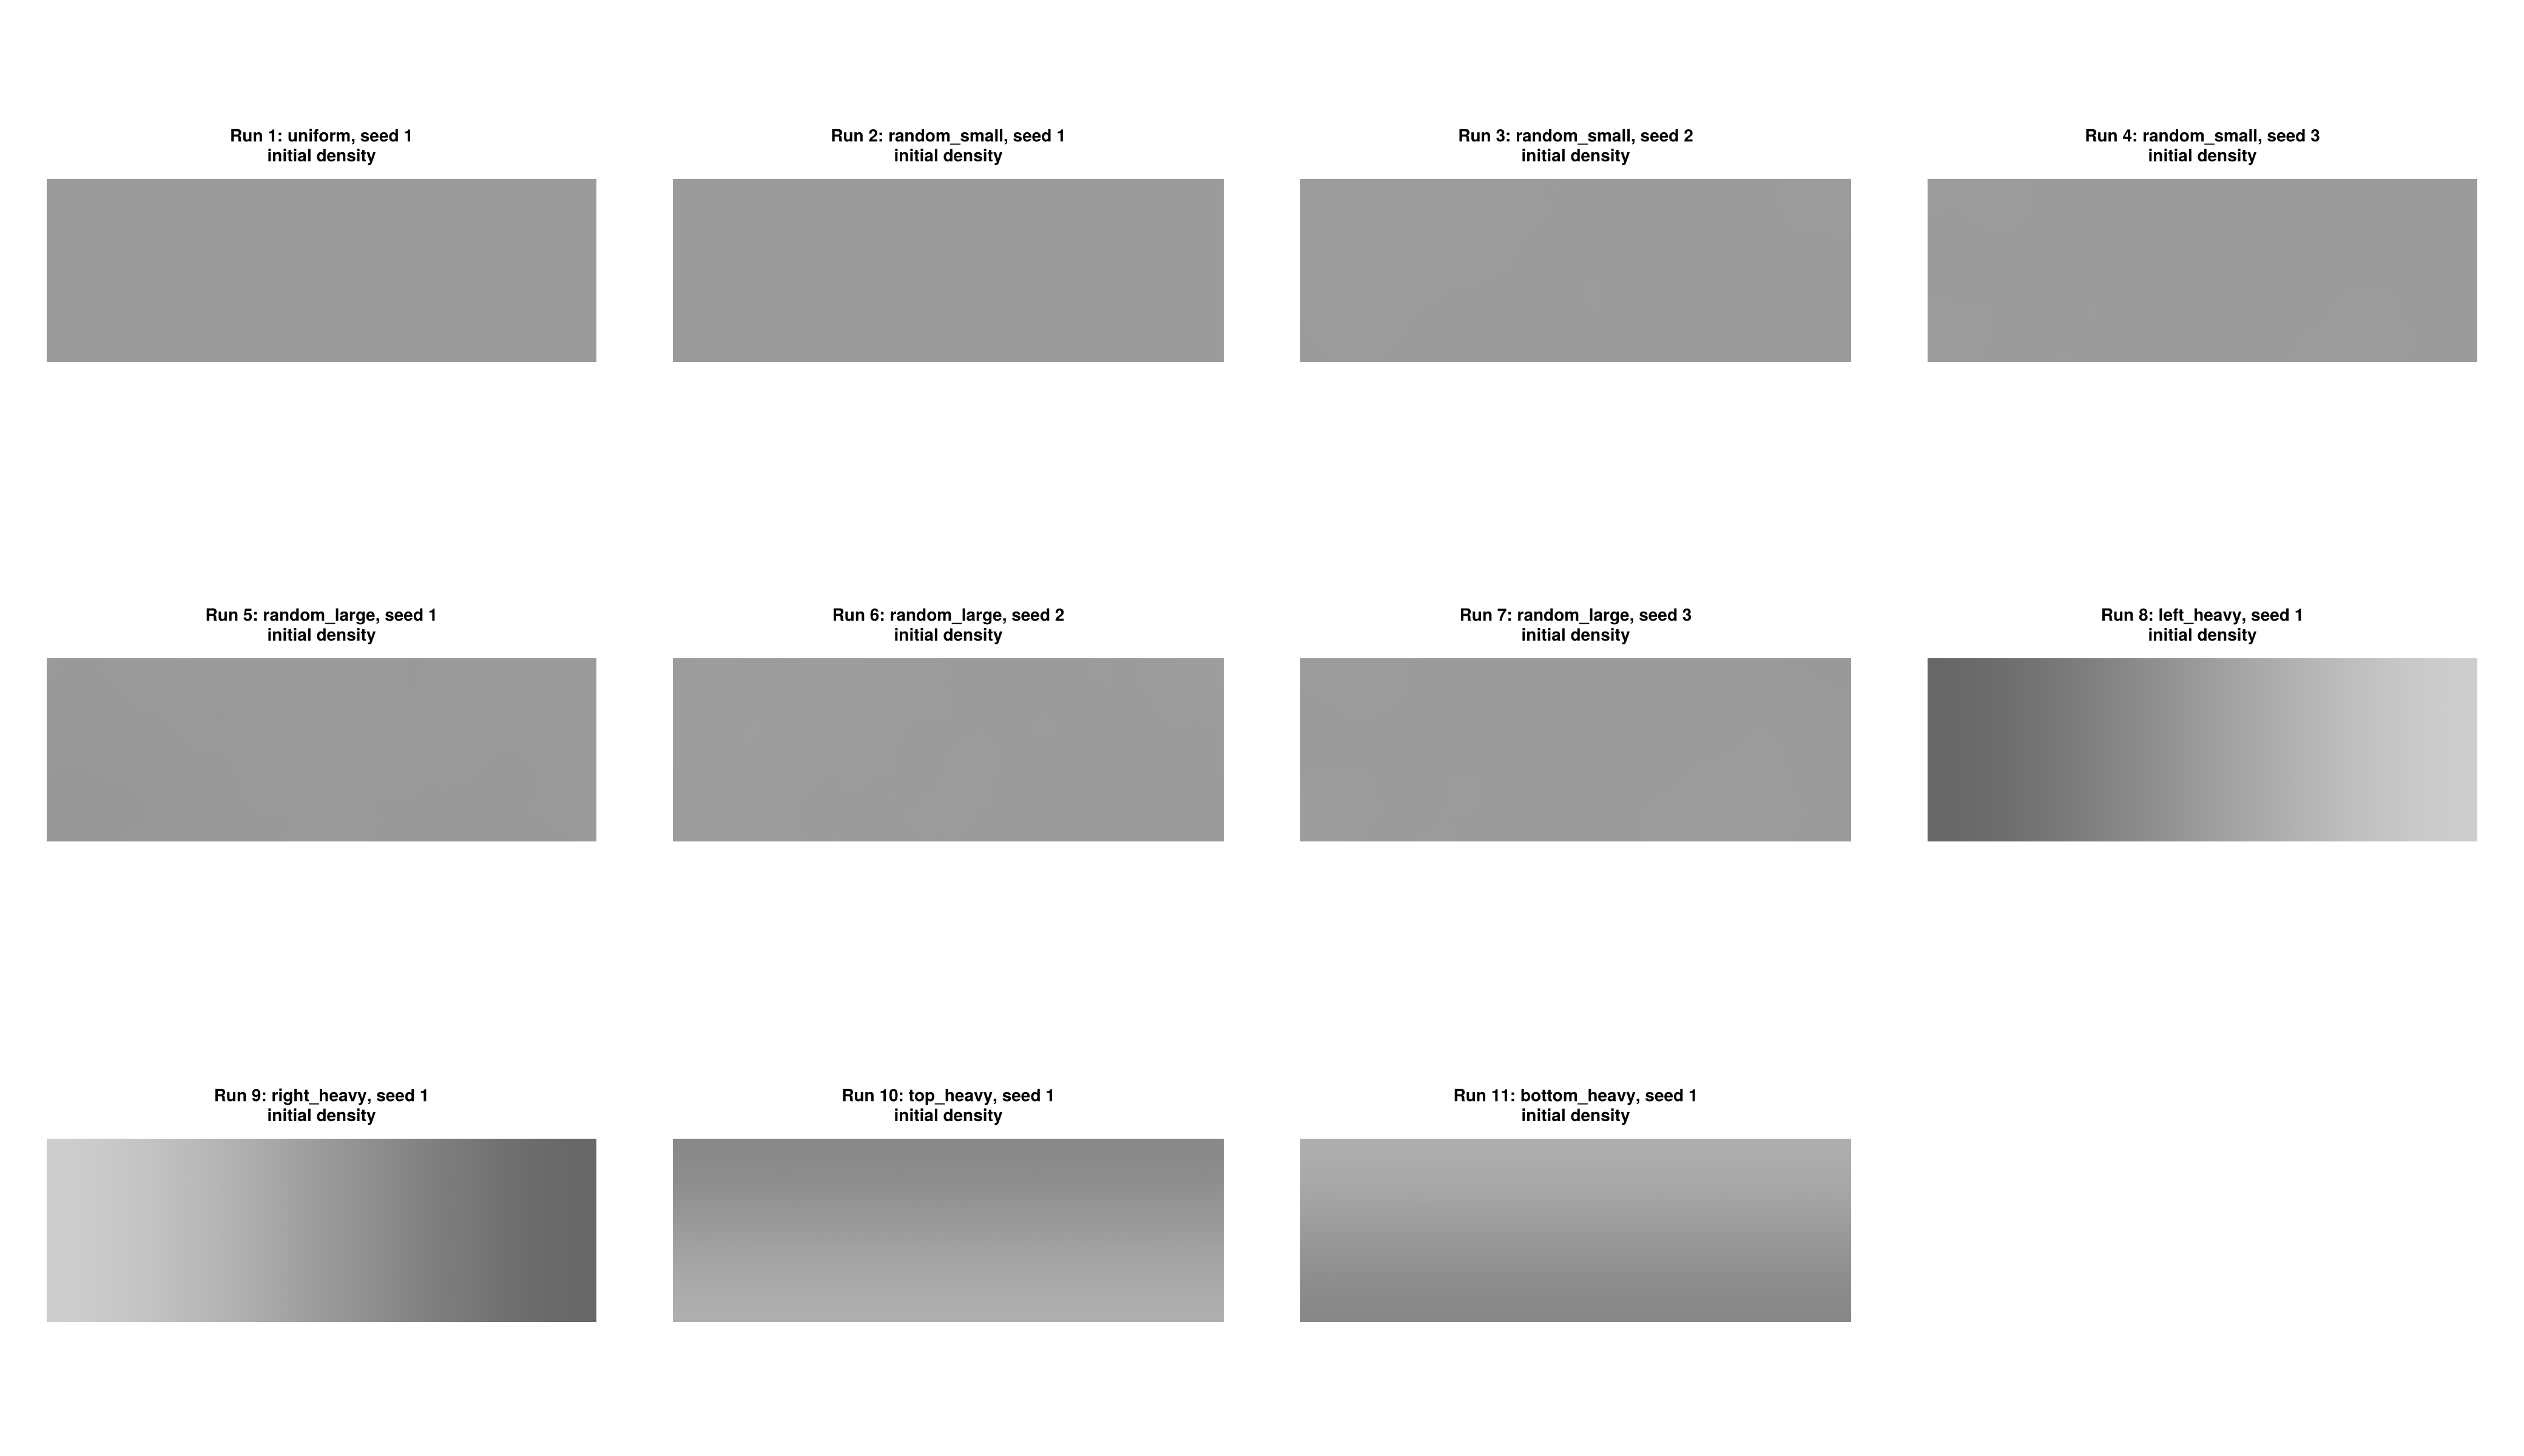

In [58]:
fig_init = plot_all_initial_sensitivity_designs(
    results;
    r=r,
    η=0.5,
    β_init=1.0,
    fem_params=fem_params,
    ncols=4,
    outfile=joinpath("SensitivityBeam", "init_sensitivity", "initial_designs_all_initializations.png")
)